# Zero-shot screening — calibration and honest head-to-head

This notebook does **not** train anything. It takes the zero-shot NLI approach from
`local_zeroshot_screening.ipynb` and fixes the things that were making it underperform,
then re-runs the comparison against embedding similarity and the TF-IDF baseline under a
protocol that is defensible in the PRISMA-ScR methods section.

## Why zero-shot, and where the usual argument for it is wrong

The intuition — *"embedding similarity looks for texts that resemble my seeds, but my
positive class is heterogeneous, so similarity is the wrong tool"* — is **half right**, and
it is worth being precise about which half, because the correct half is the one that goes in
the dissertation.

**The half that does not hold.** The embedding score used so far is
`max cosine to any positive seed − max cosine to any negative seed`. A *max over seeds* is a
multi-prototype nearest-neighbour rule, not a single-centroid rule. It does not assume the
positive class occupies one region of space; it assumes only that every region the positive
class occupies has **at least one seed in it**. So heterogeneity alone is not a defeater.

**The half that does hold, and is the real argument.** With 23 positive seeds spread over
five Alfonzo tiers and a dozen sensing modalities, coverage is almost certainly incomplete —
and the resulting blind spots are *not random*. They fall along exactly the axis this review
is mapping. If no seed covers pedestrian-level thermal comfort, the whole comfort tier is
systematically down-ranked, and the review reports a gap that the screening method
manufactured. This is the same failure mode already identified for the TITLE-only anchor
scope: a scope decision that silently removes a construct dimension rather than trading
recall against precision.

Two further reasons, both about the protocol rather than the metric:

1. **Auditability.** A hypothesis is a declarative sentence that can be printed in the
   protocol, traced to an inclusion criterion, versioned, and criticised by an examiner.
   Twenty-three seed abstracts cannot be defended the same way — "why these?" has no
   principled answer.
2. **Traceability of exclusions.** Faceted hypotheses let each exclusion be attributed to the
   adjudication rule that motivated it, so a rejected record carries a reason, not a score.

**But the evidence is currently against zero-shot** (WSS@95 of 17.5% versus 27.6% for
embeddings), and a conceptual preference is not allowed to override a measurement. So
section 8 runs the diagnostic that actually settles the question — *do the two methods miss
different dimensions?* — instead of settling it by taste.

## What is fixed here

| # | Problem in the current zero-shot cell | Fix |
|---|---|---|
| 1 | `pos_max` takes a max over hypotheses whose raw entailment scores live on wildly different scales, so one chronically-high hypothesis dominates every document | Per-hypothesis normalisation across the corpus before any aggregation (§4) |
| 2 | `pos_max * (1 - neg_max)` is an ad-hoc product with no justification | Four aggregation rules compared, including a conjunctive one that mirrors the adjudication rules (§5) |
| 3 | Each hypothesis bundles instrument + target into one sentence, so entailment has to hold for a conjunction | Hypotheses split into SENSOR / ENVIRONMENT / EXCLUSION facets, each tagged with its Alfonzo tier or adjudication rule (§3) |
| 4 | Threshold selected on the same 125 abstracts the WSS is reported on | Repeated nested cross-validation: threshold chosen in-fold, metrics measured out-of-fold, with bootstrap CIs (§6) |
| 5 | Scored one document at a time through `pipeline` (376 s for 125 docs) | Batched forward pass with cached logits — rescoring an aggregation rule costs nothing (§4) |
| 6 | Only `real.json` used as seeds, `diagnostic_test.json` as eval, so 67 of 192 labels sit idle | All 192 real labels pooled; nothing is trained on them, so CV over the pool is the honest estimator (§2) |
| 7 | WSS reported on a 39.2%-positive set and read as if it were the corpus | Prevalence correction and a sensitivity band (§9) |

## 1. Configuration

Nothing below trains a model. The only thing that gets fitted anywhere in this notebook is
a threshold — and, in strategy S3, eleven-to-twenty logistic coefficients over hypothesis
scores. Both are fitted inside cross-validation folds and evaluated out of fold.

In [1]:
# ============================================================
# 0. Imports and configuration
# ============================================================
import os, json, time, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR  = "../model/dataset"
OUT_DIR   = "../model/output"
CACHE_DIR = "../model/cache"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

POS = "Sensing of walkability dimension"
NEG = "Not related"

# Laurer et al. (2023). The -v2.0 series is binary (entailment / not_entailment);
# older MNLI checkpoints are 3-class. The scoring code below handles both.
NLI_MODEL  = "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"
EMB_MODEL  = "sentence-transformers/all-mpnet-base-v2"
MAX_LEN    = 512
BATCH_SIZE = 16

# Evaluation protocol
TARGET_RECALL = 0.95
N_SPLITS, N_REPEATS = 5, 10

# Corpus prevalence: the labelled pool is deliberately enriched and is NOT the corpus.
# Set this to your best estimate from a random corpus sample; see section 9.
CORPUS_PREVALENCE = None   # e.g. 0.20; None = skip the correction

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device} | CUDA: {torch.cuda.is_available()}")

Device: cuda | CUDA: True


## 2. The labelled pool

`real.json` (67) and `diagnostic_test.json` (125) are both real corpus abstracts, hand
labelled. In the fine-tuning notebook they had to stay apart, because `real.json` fed the
training pool. Here nothing is trained on either, so keeping them separate only throws away
statistical power. They are pooled into a single evaluation set of ~192 abstracts, with the
origin retained so any origin effect stays visible.

In [2]:
# ============================================================
# 1. Load and pool the real labelled abstracts
# ============================================================
def load_json(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return json.load(f)

frames = []
for name in ["real", "diagnostic_test"]:
    p = f"{DATA_DIR}/{name}.json"
    if not os.path.exists(p):
        print(f"  [missing] {p}"); continue
    d = pd.DataFrame(load_json(p))[["text", "label"]]
    d["origin"] = name
    frames.append(d)
    print(f"  {name:16s} -> {len(d):4d}")

pool = pd.concat(frames, ignore_index=True)
pool["text"] = pool["text"].astype(str).str.strip()

# de-duplicate across the two files (they were built separately)
n0 = len(pool)
pool["key"] = pool["text"].str.lower().str.replace(r"[^a-z0-9 ]", " ", regex=True) \
                          .str.replace(r"\s+", " ", regex=True).str.strip()
conflict = pool.groupby("key")["label"].nunique().loc[lambda s: s > 1]
if len(conflict):
    print(f"\n[!] {len(conflict)} texts with conflicting labels across files - dropped, "
          f"resolve manually:")
    for k in list(conflict.index)[:3]:
        print("   -", pool[pool.key == k]["text"].iloc[0][:120], "...")
    pool = pool[~pool["key"].isin(conflict.index)]
pool = pool.drop_duplicates("key").reset_index(drop=True)
print(f"\nPooled: {n0} -> {len(pool)} after de-duplication")

pool["y"] = (pool["label"] == POS).astype(int)
y = pool["y"].values
print(f"Positives {y.sum()} ({y.mean()*100:.1f}%) | negatives {(1-y).sum()}")
print(pool.groupby(['origin', 'label']).size().to_string())

if y.sum() < 40:
    print("\n[!] Fewer than 40 positives. Every estimate below will be wide. "
          "Labelling ~150 more random corpus abstracts is the highest-value "
          "thing you can do for this pipeline.")

  real             ->   67
  diagnostic_test  ->  125

Pooled: 192 -> 192 after de-duplication
Positives 72 (37.5%) | negatives 120
origin           label                           
diagnostic_test  Not related                         76
                 Sensing of walkability dimension    49
real             Not related                         44
                 Sensing of walkability dimension    23


## 3. Faceted hypothesis bank

The inclusion criterion is a **conjunction**, not a single proposition:

> a study is eligible if *(a sensing instrument acquires data)* **AND** *(what is measured is
> an attribute of the pedestrian environment)* **AND NOT** *(one of the three adjudication
> rules excludes it)*.

Writing that as one sentence — *"This study uses sensors to measure the physical condition of
sidewalks"* — asks the NLI model to certify a conjunction from an abstract that usually states
the two halves in different sentences. Entailment scores for conjunctions are systematically
low and noisy, which is a large part of why recall collapsed above threshold 0.05.

Splitting into facets lets the two halves be scored independently and combined explicitly.
It also makes the exclusion side legible: every negative hypothesis is tagged with the
adjudication rule it operationalises, so a rejected record carries a reason.

`tier` maps each ENVIRONMENT hypothesis to the expanded Alfonzo grid. That tag is what
section 8 uses to test whether either method has dimension-shaped blind spots.

**Edit these sentences, re-run, and compare.** Short, concrete, declarative, one proposition
each. Because logits are cached per hypothesis text, editing one sentence only rescores that
one.

In [3]:
# ============================================================
# 2. Hypothesis bank - facet | tier/rule | sentence
# ============================================================
HYPOTHESES = [
    # ---------- SENSOR facet: is there an instrument acquiring data? ----------
    ("sensor", "field_device",   "The study collects data with a physical sensor, camera or measurement device placed in the field."),
    ("sensor", "street_imagery", "The study derives measurements from street-level photographs such as Google Street View panoramas."),
    ("sensor", "lidar",          "The study uses LiDAR, point clouds or depth sensing to measure physical geometry."),
    ("sensor", "mobile",         "The study uses smartphone sensors, wearable devices or accelerometers to record conditions along a route."),
    ("sensor", "environmental",  "The study uses instruments to record temperature, noise or air pollution at a specific location."),
    ("sensor", "cv",             "The study applies computer vision or deep learning to images in order to extract measurements."),

    # ---------- ENVIRONMENT facet: is the measured object a walkability attribute? ----------
    ("env", "feasibility",    "The measured object is the sidewalk surface, its width, its continuity or its state of repair."),
    ("env", "accessibility",  "The measured object is slope, steps, kerb ramps or physical barriers along a pedestrian route."),
    ("env", "accessibility",  "The measured object is the layout or connectivity of the pedestrian network."),
    ("env", "safety",         "The measured object is pedestrian crossing infrastructure, street lighting or exposure to vehicle traffic."),
    ("env", "comfort",        "The measured object is thermal comfort, shade, noise or air quality experienced by a person on the street."),
    ("env", "pleasurability", "The measured object is street greenery, building facades, enclosure or the visual quality of the streetscape."),
    ("env", "general",        "The measured object is a physical characteristic of the street environment where people walk."),
    ("env", "walkability",    "The study assesses the walkability of an urban area."),

    # ---------- EXCLUSION facet: tagged with the adjudication rule ----------
    ("excl", "rule1_source",    "The measurements are taken from satellite or aerial imagery captured from above, not from ground level."),
    ("excl", "rule2_stimulus",  "Images are shown to human participants as stimuli in a survey or a preference experiment."),
    ("excl", "rule3_construct", "The outcome of interest is crime risk, property value, housing price or gentrification."),
    ("excl", "outcome_health",  "The outcome of interest is the physical activity, health or step count of individuals."),
    ("excl", "outcome_behav",   "The study measures where people walk or how much they walk, rather than the street they walk on."),
    ("excl", "off_domain",      "The study is about vehicles, cyclists, e-scooters, robots or autonomous driving."),
    ("excl", "clinical",        "The study analyses clinical gait, patient rehabilitation or laboratory walkway experiments."),
    ("excl", "no_sensor",       "The measure is computed from geographic databases or census data without any sensing."),
    ("excl", "simulation",      "The results come from a simulation or an agent-based model rather than from field measurement."),
]

H = pd.DataFrame(HYPOTHESES, columns=["facet", "tag", "text"])
assert H["text"].is_unique, "Duplicate hypothesis sentences."
print(H.groupby("facet").size().to_string())
print(f"\nTotal hypotheses: {len(H)}")

IS_SENS = (H.facet == "sensor").values
IS_ENV  = (H.facet == "env").values
IS_EXCL = (H.facet == "excl").values

facet
env       8
excl      9
sensor    6

Total hypotheses: 23


## 4. Batched scoring, with caching

Two changes from the original cell. First, documents and hypotheses are batched into a
single forward pass instead of one `pipeline` call per document — the same 125 abstracts
that took 376 s take well under a minute. Second, **raw logits are cached to disk keyed by
(model, hypothesis text, document text)**. Every aggregation rule, normalisation and
threshold in the rest of the notebook is then free to recompute, which is what makes
calibration practical: you tune the combination, not the model.

The entailment probability is taken as softmax over `{entailment, contradiction}` for
3-class MNLI checkpoints and over both classes for the binary `-v2.0` series, which is the
standard `multi_label=True` treatment.

In [4]:
# ============================================================
# 3. Cached, batched NLI scoring
# ============================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification

_tok = _mdl = None
def _load_nli():
    global _tok, _mdl
    if _mdl is None:
        _tok = AutoTokenizer.from_pretrained(NLI_MODEL)
        _mdl = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL).to(device).eval()
        if device == "cuda":
            _mdl = _mdl.half()
        print(f"Loaded {NLI_MODEL} | labels: {_mdl.config.id2label}")
    return _tok, _mdl

def _entail_index(cfg):
    '''Locate entailment (and contradiction, if present) in the model config.'''
    lab = {v.lower(): k for k, v in cfg.id2label.items()}
    ent = next((i for n, i in lab.items() if n.startswith("entail")), 0)
    con = next((i for n, i in lab.items() if n.startswith("contra")), None)
    return ent, con

def _cache_path(doc_texts, hyp_text):
    h = hashlib.sha1()
    h.update(NLI_MODEL.encode()); h.update(b"|"); h.update(hyp_text.encode())
    h.update(b"|"); h.update(str(len(doc_texts)).encode())
    for t in doc_texts:
        h.update(t[:400].encode("utf-8", "ignore"))
    return f"{CACHE_DIR}/nli_{h.hexdigest()[:20]}.npy"

@torch.no_grad()
def score_hypothesis(doc_texts, hyp_text, use_cache=True):
    '''Return p(entailment) of hyp_text for each document. Cached on disk.'''
    cp = _cache_path(doc_texts, hyp_text)
    if use_cache and os.path.exists(cp):
        return np.load(cp)
    tok, mdl = _load_nli()
    ent, con = _entail_index(mdl.config)
    out = []
    for i in range(0, len(doc_texts), BATCH_SIZE):
        chunk = doc_texts[i:i + BATCH_SIZE]
        enc = tok(chunk, [hyp_text] * len(chunk), truncation="only_first",
                  max_length=MAX_LEN, padding=True, return_tensors="pt").to(device)
        logits = mdl(**enc).logits.float()
        sel = logits[:, [ent, con]] if con is not None else logits
        out.append(torch.softmax(sel, dim=-1)[:, 0].cpu().numpy())
    p = np.concatenate(out)
    np.save(cp, p)
    return p

def score_matrix(doc_texts, hyp_df, label=""):
    '''Documents x hypotheses matrix of entailment probabilities.'''
    doc_texts = list(doc_texts)
    P = np.zeros((len(doc_texts), len(hyp_df)), dtype=np.float32)
    t0 = time.time()
    for j, h in enumerate(hyp_df["text"]):
        P[:, j] = score_hypothesis(doc_texts, h)
        print(f"  [{j+1:2d}/{len(hyp_df)}] {time.time()-t0:5.0f}s  {h[:64]}...")
    print(f"{label} scored in {time.time()-t0:.0f}s")
    return P

P = score_matrix(pool["text"].tolist(), H, "Labelled pool")
np.save(f"{OUT_DIR}/nli_matrix_pool.npy", P)
print(f"\nMatrix: {P.shape}")

Loaded MoritzLaurer/deberta-v3-large-zeroshot-v2.0 | labels: {0: 'entailment', 1: 'not_entailment'}
  [ 1/23]    74s  The study collects data with a physical sensor, camera or measur...
  [ 2/23]   135s  The study derives measurements from street-level photographs suc...
  [ 3/23]   196s  The study uses LiDAR, point clouds or depth sensing to measure p...
  [ 4/23]   258s  The study uses smartphone sensors, wearable devices or accelerom...
  [ 5/23]   323s  The study uses instruments to record temperature, noise or air p...
  [ 6/23]   390s  The study applies computer vision or deep learning to images in ...
  [ 7/23]   457s  The measured object is the sidewalk surface, its width, its cont...
  [ 8/23]   525s  The measured object is slope, steps, kerb ramps or physical barr...
  [ 9/23]   590s  The measured object is the layout or connectivity of the pedestr...
  [10/23]   658s  The measured object is pedestrian crossing infrastructure, stree...
  [11/23]   726s  The measured object is

### 4b. Why the raw scores could not be combined with `max`

The table below is the diagnostic that explains most of the original result. Each hypothesis
has its own baseline entailment rate — some sentences are entailed by almost any urban
abstract, others by almost none. `pos_max` therefore does not select *the hypothesis that
best describes this document*; it selects *the hypothesis with the highest intercept*,
almost always the same one, for every document in the corpus. The other four positive
hypotheses contribute nothing.

Normalising each hypothesis column across the corpus removes the intercept and leaves the
part that actually varies by document. Z-scoring assumes roughly symmetric scores;
rank-normalisation makes no distributional assumption and is the safer default when the
score distribution is skewed, as entailment scores usually are. Both are available via
`NORM`.

Note that this normalisation uses **corpus statistics only** — no labels — so it can be
applied to the full 1,696-record corpus without any leakage concern.

In [5]:
# ============================================================
# 4. Per-hypothesis diagnostics and normalisation
# ============================================================
diag_h = H.copy()
diag_h["mean"]     = P.mean(axis=0).round(3)
diag_h["std"]      = P.std(axis=0).round(3)
diag_h["p90"]      = np.percentile(P, 90, axis=0).round(3)
diag_h["auc"]      = [round(roc_auc_score(y, P[:, j]), 3) for j in range(P.shape[1])]
diag_h["argmax_share"] = 0.0
for facet in ["sensor", "env", "excl"]:
    cols = np.where((H.facet == facet).values)[0]
    if len(cols) == 0: continue
    winner = cols[P[:, cols].argmax(axis=1)]
    share = pd.Series(winner).value_counts(normalize=True)
    for c, v in share.items():
        diag_h.loc[c, "argmax_share"] = round(v, 3)

print("AUC is computed against the eligibility label, so ~0.5 means the sentence carries no")
print("signal and <0.5 means it is an inverted signal (fine for exclusion hypotheses).")
print("argmax_share = how often this hypothesis wins the max WITHIN its facet.\n")
print(diag_h[["facet", "tag", "mean", "std", "p90", "auc", "argmax_share", "text"]]
      .assign(text=lambda d: d.text.str.slice(0, 52))
      .to_string(index=False))

dominant = diag_h.loc[diag_h.groupby("facet")["argmax_share"].idxmax()]
print("\nMost dominant hypothesis per facet (this is what a raw `max` was returning):")
print(dominant[["facet", "tag", "argmax_share"]].to_string(index=False))

# ---- normalisation ----
NORM = "rank"     # "rank" | "z" | "none"

def normalise(M, how=NORM, ref=None):
    '''Column-wise normalisation using corpus statistics (label-free).'''
    ref = M if ref is None else ref
    if how == "none":
        return M.copy()
    if how == "z":
        mu, sd = ref.mean(axis=0), ref.std(axis=0) + 1e-9
        return (M - mu) / sd
    if how == "rank":
        out = np.zeros_like(M, dtype=np.float32)
        for j in range(M.shape[1]):
            out[:, j] = np.searchsorted(np.sort(ref[:, j]), M[:, j], side="left") / len(ref)
        return (out - 0.5) * 3.46          # roughly unit variance, comparable to z
    raise ValueError(how)

Z = normalise(P)
print(f"\nNormalisation: {NORM} | column means {Z.mean(axis=0).round(2)[:5]} ...")

AUC is computed against the eligibility label, so ~0.5 means the sentence carries no
signal and <0.5 means it is an inverted signal (fine for exclusion hypotheses).
argmax_share = how often this hypothesis wins the max WITHIN its facet.

 facet             tag  mean   std   p90   auc  argmax_share                                                 text
sensor    field_device 0.181 0.237 0.588 0.572         0.188 The study collects data with a physical sensor, came
sensor  street_imagery 0.101 0.225 0.447 0.688         0.031 The study derives measurements from street-level pho
sensor           lidar 0.138 0.214 0.258 0.473         0.255 The study uses LiDAR, point clouds or depth sensing 
sensor          mobile 0.083 0.186 0.213 0.461         0.115 The study uses smartphone sensors, wearable devices 
sensor   environmental 0.039 0.128 0.045 0.587         0.010 The study uses instruments to record temperature, no
sensor              cv 0.335 0.393 0.970 0.758         0.401 The study applies

## 5. Aggregation strategies

Five rules, from the one currently in use to a supervised combination. The point of running
all five is that the differences between them are *interpretable* — if S2 beats S1, the
conjunction matters; if S3 beats S2, the hand-written weighting of facets is wrong and the
coefficients will say how.

| | Rule | Fitted? |
|---|---|---|
| **S0** | `pos_max × (1 − neg_max)` on raw scores — reproduces the current cell | no |
| **S1** | `max(normalised positives) − max(normalised exclusions)` | no |
| **S2** | `min(max sensor, max env) − max(exclusions)` — conjunctive, mirrors the criterion | no |
| **S3** | `soft-min(sensor, env) − λ·max(exclusions)`, λ swept | one scalar |
| **S4** | logistic regression on all hypothesis columns | k coefficients |

S2 is the one that encodes the actual inclusion rule: a `min` over the two required facets is
a conjunction (a document scores high only if *both* halves hold), where a `max` or a sum lets
a strong sensor signal alone carry a document through. That is precisely the error mode in
the fine-tuned model's confusion matrix — `Autonomous navigation of a mobile robot...` and
`Measuring Streetscape Features with High-Density Aerial LiDAR` were both false positives with
confidence > 0.9, and both are sensor-strong, environment-wrong or rule-1-excluded.

S4 is supervised and therefore only honest under cross-validation, which is what §6 does. It
is included because it sets an upper bound: if S4 barely beats S2, the hand-written rule is
already extracting what the hypotheses contain, and further effort belongs in the hypothesis
wording rather than in the combination.

In [6]:
# ============================================================
# 5. Aggregation rules
# ============================================================
def softmin(a, b, beta=6.0):
    '''Smooth minimum - differentiable conjunction, less brittle than hard min.'''
    return -np.log(np.exp(-beta * a) + np.exp(-beta * b) + 1e-12) / beta

def agg_S0(Praw, **kw):
    pos = Praw[:, IS_SENS | IS_ENV].max(axis=1)
    neg = Praw[:, IS_EXCL].max(axis=1)
    return pos * (1 - neg)

def agg_S1(Zn, **kw):
    return Zn[:, IS_SENS | IS_ENV].max(axis=1) - Zn[:, IS_EXCL].max(axis=1)

def agg_S2(Zn, **kw):
    return np.minimum(Zn[:, IS_SENS].max(axis=1),
                      Zn[:, IS_ENV].max(axis=1)) - Zn[:, IS_EXCL].max(axis=1)

def agg_S3(Zn, lam=1.0, beta=6.0, **kw):
    return softmin(Zn[:, IS_SENS].max(axis=1),
                   Zn[:, IS_ENV].max(axis=1), beta) - lam * Zn[:, IS_EXCL].max(axis=1)

UNSUPERVISED = {
    "S0 raw pos_max*(1-neg_max)": lambda: agg_S0(P),
    "S1 norm pos_max - excl_max": lambda: agg_S1(Z),
    "S2 conjunctive min(S,E) - excl": lambda: agg_S2(Z),
    "S3 softmin, lambda=1.0": lambda: agg_S3(Z, lam=1.0),
}

print("Ranking quality (ROC-AUC on the labelled pool, no threshold involved):\n")
for name, fn in UNSUPERVISED.items():
    s = fn()
    print(f"  {name:34s} AUC {roc_auc_score(y, s):.3f}")

# lambda sweep for S3
print("\nS3 exclusion weight sweep:")
for lam in [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
    print(f"  lambda={lam:4.2f}  AUC {roc_auc_score(y, agg_S3(Z, lam=lam)):.3f}")

Ranking quality (ROC-AUC on the labelled pool, no threshold involved):

  S0 raw pos_max*(1-neg_max)         AUC 0.820
  S1 norm pos_max - excl_max         AUC 0.795
  S2 conjunctive min(S,E) - excl     AUC 0.840
  S3 softmin, lambda=1.0             AUC 0.844

S3 exclusion weight sweep:
  lambda=0.00  AUC 0.792
  lambda=0.25  AUC 0.823
  lambda=0.50  AUC 0.836
  lambda=0.75  AUC 0.842
  lambda=1.00  AUC 0.844
  lambda=1.50  AUC 0.842
  lambda=2.00  AUC 0.830


## 6. Evaluation protocol

The number that goes in the dissertation is **WSS@95** — work saved over sampling at 95%
recall (Cohen et al. 2006; O'Mara-Eves et al. 2015). It has a well-known failure mode when
reported carelessly: pick the threshold that maximises WSS *on the same data used to measure
it*, and the estimate is optimistic by an amount nobody can bound. That is what the current
notebook does, for all three approaches, so its head-to-head is not decidable.

Here the threshold is a fitted parameter like any other. Repeated stratified 5-fold CV:
choose the threshold on four folds at the target recall, apply it to the held-out fold,
pool the out-of-fold predictions, compute the metric once. Repeated ten times with different
partitions, then bootstrapped for a confidence interval.

For the supervised strategies (S4, TF-IDF, embeddings) the model *and* the threshold are
fitted inside the fold. That puts every approach on the same footing, which is the only way
the comparison means anything.

In [ ]:
# ============================================================
# 6. Nested threshold selection + out-of-fold evaluation
# ============================================================
def pick_threshold(scores, yy, target=TARGET_RECALL):
    '''Lowest-workload threshold still reaching target recall on the fit fold.
    Vectorised: sort once, walk the cumulative TP curve. Equivalent to sweeping
    every candidate cut, but O(n log n) instead of O(n^2) - which matters because
    this is called inside every fold of every repeat of every strategy.'''
    n_pos = int(yy.sum())
    if n_pos == 0:
        return float(scores.max()) + 1e-9
    order = np.argsort(-scores, kind="mergesort")
    recall_curve = np.cumsum(yy[order]) / n_pos
    hit = np.flatnonzero(recall_curve >= target)
    if len(hit) == 0:
        return float(scores.min()) - 1e-9
    return float(scores[order][hit[0]])

def wss(yy, pred, target=TARGET_RECALL):
    rec = recall_score(yy, pred, zero_division=0)
    return (1 - pred.mean()) - (1 - rec), rec      # recall alcançado

def evaluate(name, score_fn, yy=y, n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=SEED):
    '''score_fn(train_idx, test_idx) -> scores for ALL rows.
       Threshold fitted on train_idx, prediction read on test_idx.'''
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    per_rep = []
    oof_pred = np.zeros((n_repeats, len(yy)), dtype=int)
    oof_score = np.zeros((n_repeats, len(yy)), dtype=float)
    for k, (tr, te) in enumerate(rskf.split(np.zeros(len(yy)), yy)):
        rep = k // n_splits
        s = score_fn(tr, te)
        thr = pick_threshold(s[tr], yy[tr])
        oof_pred[rep, te] = (s[te] >= thr).astype(int)
        oof_score[rep, te] = s[te]
    for rep in range(n_repeats):
        w, rec = wss(yy, oof_pred[rep])
        per_rep.append({
            "WSS@95": 100 * w,
            "recall": rec,
            "precision": precision_score(yy, oof_pred[rep], zero_division=0),
            "pct_discarded": 100 * (1 - oof_pred[rep].mean()),
            "missed": int(((yy == 1) & (oof_pred[rep] == 0)).sum()),
            "AUC": roc_auc_score(yy, oof_score[rep]),
        })
    d = pd.DataFrame(per_rep)
    lo, hi = np.percentile(d["WSS@95"], [2.5, 97.5])
    return ({"approach": name,
             "WSS@95": round(d["WSS@95"].mean(), 1),
             "WSS_lo": round(lo, 1), "WSS_hi": round(hi, 1),
             "recall": round(d["recall"].mean(), 3),
             "precision": round(d["precision"].mean(), 3),
             "pct_discarded": round(d["pct_discarded"].mean(), 1),
             "missed": round(d["missed"].mean(), 1),
             "AUC": round(d["AUC"].mean(), 3)},
            oof_score.mean(axis=0))

results, oof = [], {}
for name, fn in UNSUPERVISED.items():
    s_all = fn()
    r, o = evaluate(name, lambda tr, te, s=s_all: s)
    results.append(r); oof[name] = o
    print(f"  done: {name}")

print()
print(pd.DataFrame(results).to_string(index=False))

  done: S0 raw pos_max*(1-neg_max)
  done: S1 norm pos_max - excl_max
  done: S2 conjunctive min(S,E) - excl
  done: S3 softmin, lambda=1.0

                      approach  WSS@95  WSS_lo  WSS_hi  recall  precision  pct_discarded  missed   AUC
    S0 raw pos_max*(1-neg_max)    16.7    15.0    18.6   0.950      0.455           21.7     3.6 0.820
    S1 norm pos_max - excl_max    13.0    11.7    15.3   0.962      0.440           18.0     2.7 0.795
S2 conjunctive min(S,E) - excl    23.5    21.7    25.1   0.951      0.499           28.5     3.5 0.840
        S3 softmin, lambda=1.0    24.1    22.7    25.6   0.951      0.503           29.1     3.5 0.844


## 7. Supervised comparators, under the same protocol

Three additions, all fitted strictly inside the fold:

- **S4** — logistic regression on the hypothesis columns. The hypotheses stay the semantic
  engine; the labels only decide how to weigh them. With ~192 labels and ~23 features this is
  a modest ask, and the coefficients are printed because they are diagnostic in their own
  right: a positive coefficient on an exclusion hypothesis means that sentence is mis-tagged.
- **Embeddings** — the same `max cosine − max cosine` rule as before, but with the seed set
  restricted to the training fold each time, which is what the earlier notebook could not do
  (it used all of `real.json` as seeds and evaluated on `diagnostic_test.json`, so the seed
  count was fixed and the two were never on the same protocol).
- **TF-IDF + logistic regression** — the linear baseline. It has already matched fine-tuned
  DeBERTa once, so it stays in the table permanently; a reviewer will ask.

In [8]:
# ============================================================
# 7. S4, embeddings, TF-IDF - all fold-internal
# ============================================================
texts = pool["text"].tolist()

# ---- S4: logistic over hypothesis scores ----
def s4_scores(tr, te):
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, C=0.5,
                                           class_weight="balanced", random_state=SEED))
    clf.fit(Z[tr], y[tr])
    return clf.predict_proba(Z)[:, 1]

r, o = evaluate("S4 logistic on hypothesis scores", s4_scores)
results.append(r); oof["S4 logistic on hypothesis scores"] = o
print("  done: S4")

# ---- embeddings ----
from sentence_transformers import SentenceTransformer
emb_model = SentenceTransformer(EMB_MODEL, device=device)
E = emb_model.encode(texts, normalize_embeddings=True, show_progress_bar=True,
                     batch_size=32)
np.save(f"{OUT_DIR}/emb_pool.npy", E)

SIM = E @ E.T
np.fill_diagonal(SIM, -np.inf)

def emb_scores(tr, te):
    pos_seeds = tr[y[tr] == 1]
    neg_seeds = tr[y[tr] == 0]
    return SIM[:, pos_seeds].max(axis=1) - SIM[:, neg_seeds].max(axis=1)

r, o = evaluate("Embedding max-sim (fold seeds)", emb_scores)
results.append(r); oof["Embedding max-sim (fold seeds)"] = o
print("  done: embeddings")

# ---- TF-IDF baseline ----
def tfidf_scores(tr, te):
    clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                        LogisticRegression(max_iter=2000, class_weight="balanced",
                                           random_state=SEED))
    clf.fit([texts[i] for i in tr], y[tr])
    return clf.predict_proba(texts)[:, 1]

r, o = evaluate("TF-IDF + LogReg baseline", tfidf_scores)
results.append(r); oof["TF-IDF + LogReg baseline"] = o
print("  done: TF-IDF")

# ---- hybrid: hypotheses + embedding similarity as one extra feature ----
def hybrid_scores(tr, te):
    extra = emb_scores(tr, te).reshape(-1, 1)
    Xh = np.hstack([Z, extra])
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, C=0.5,
                                           class_weight="balanced", random_state=SEED))
    clf.fit(Xh[tr], y[tr])
    return clf.predict_proba(Xh)[:, 1]

r, o = evaluate("Hybrid (hypotheses + embedding)", hybrid_scores)
results.append(r); oof["Hybrid (hypotheses + embedding)"] = o
print("  done: hybrid")

# ---- reference row from the fine-tuned model ----
results.append({"approach": "Fine-tuned DeBERTa (reported)", "WSS@95": 12.4,
                "WSS_lo": np.nan, "WSS_hi": np.nan, "recall": 0.980,
                "precision": 0.449, "pct_discarded": 14.4, "missed": np.nan,
                "AUC": np.nan})

table = pd.DataFrame(results).sort_values("WSS@95", ascending=False)
print("\n" + "=" * 100)
print("HEAD-TO-HEAD - all rows except the last measured out-of-fold, threshold fitted in-fold")
print("=" * 100)
print(table.to_string(index=False))
print(f"\nBenchmark (O'Mara-Eves et al. 2015): 30-70% workload saving at ~95% recall.")
print("Overlapping [WSS_lo, WSS_hi] intervals mean the difference is not resolvable")
print(f"with {len(pool)} labels - report that rather than picking a winner.")

table.to_csv(f"{OUT_DIR}/screening_head_to_head.csv", index=False)

  done: S4


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

  done: embeddings
  done: TF-IDF
  done: hybrid

HEAD-TO-HEAD - all rows except the last measured out-of-fold, threshold fitted in-fold
                        approach  WSS@95  WSS_lo  WSS_hi  recall  precision  pct_discarded  missed   AUC
        TF-IDF + LogReg baseline    83.5    82.6    85.0   0.278      0.909           88.5    52.0 0.870
 Hybrid (hypotheses + embedding)    45.9    43.7    47.5   0.868      0.663           50.9     9.5 0.896
S4 logistic on hypothesis scores    40.3    34.2    44.4   0.876      0.602           45.3     8.9 0.866
  Embedding max-sim (fold seeds)    29.7    26.4    34.8   0.962      0.553           34.7     2.7 0.870
          S3 softmin, lambda=1.0    24.1    22.7    25.6   0.951      0.503           29.1     3.5 0.844
  S2 conjunctive min(S,E) - excl    23.5    21.7    25.1   0.951      0.499           28.5     3.5 0.840
      S0 raw pos_max*(1-neg_max)    16.7    15.0    18.6   0.950      0.455           21.7     3.6 0.820
      S1 norm pos_max -

## 8. The diagnostic that actually decides the question

Everything above compares methods on aggregate workload. Aggregate workload is not what makes
a screening method acceptable or unacceptable in a mapping review — **the distribution of the
misses is**. A method that loses 5% of eligible records uniformly at random costs a little
recall. A method that loses 5% *concentrated in one Alfonzo tier* changes the finding, because
the review's contribution is a claim about which dimensions the sensing literature covers.

Each positive record is assigned a proxy tier: the ENVIRONMENT hypothesis with the highest
normalised score. This is a proxy, not a hand label — say so if it goes in the text — but it is
enough to expose a systematic hole.

The question is not *which method has the better WSS*. It is **does either method's miss
profile depend on the tier**. If the embedding method's misses concentrate in tiers that its
seeds under-cover while the hypothesis method's are flat, that is the argument for zero-shot,
it is empirical rather than intuitive, and it is a methodological finding worth a paragraph in
its own right.

Proxy tier distribution among eligible records (argmax over ENVIRONMENT hypotheses):
proxy_tier
comfort           17
accessibility     17
pleasurability    12
general            9
feasibility        6
walkability        6
safety             5

Miss rate by tier at the target-recall threshold (lower is better, FLAT is what matters):
approach        n_eligible  Embedding max-sim (fold seeds)  Hybrid (hypotheses + embedding)  S1 norm pos_max - excl_max  S2 conjunctive min(S,E) - excl  S3 softmin, lambda=1.0  S4 logistic on hypothesis scores  TF-IDF + LogReg baseline
tier                                                                                                                                                                                                                                       
accessibility           17                           0.059                            0.059                       0.059                           0.059                   0.059                   

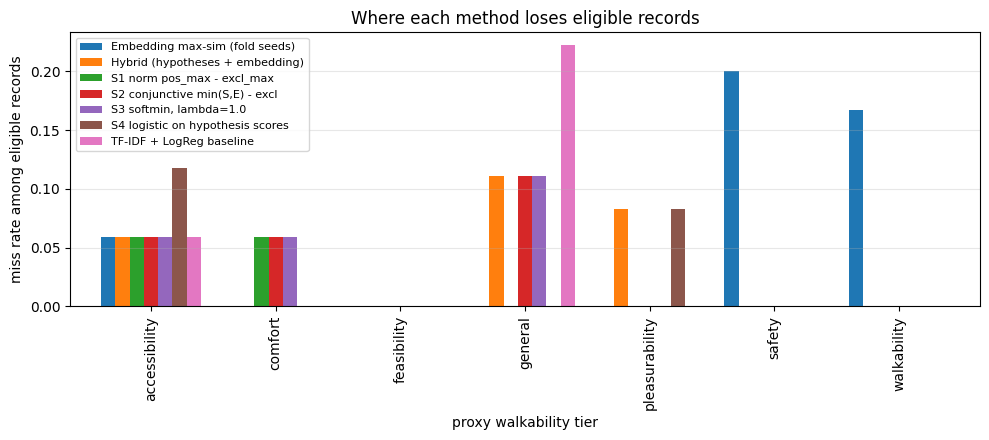

In [9]:
# ============================================================
# 8. Miss profile by walkability tier
# ============================================================
env_cols = np.where(IS_ENV)[0]
env_tags = H.loc[env_cols, "tag"].values
pool["proxy_tier"] = env_tags[Z[:, env_cols].argmax(axis=1)]

pos_mask = y == 1
print("Proxy tier distribution among eligible records "
      "(argmax over ENVIRONMENT hypotheses):")
print(pool.loc[pos_mask, "proxy_tier"].value_counts().to_string())

COMPARE = [n for n in oof if n != "S0 raw pos_max*(1-neg_max)"]
rows = []
for name in COMPARE:
    s = oof[name]
    thr = pick_threshold(s, y)                 # single global threshold, for comparability
    missed = pos_mask & (s < thr)
    for tier, grp in pool[pos_mask].groupby("proxy_tier"):
        idx = grp.index.values
        rows.append({"approach": name, "tier": tier, "n_eligible": len(idx),
                     "n_missed": int(missed[idx].sum()),
                     "miss_rate": round(missed[idx].mean(), 3)})
miss = pd.DataFrame(rows)
pivot = miss.pivot(index="tier", columns="approach", values="miss_rate")
counts = miss.groupby("tier")["n_eligible"].first()
pivot.insert(0, "n_eligible", counts)
print("\nMiss rate by tier at the target-recall threshold (lower is better, "
      "FLAT is what matters):")
print(pivot.round(3).to_string())

print("\nDispersion of the miss rate across tiers - the number to compare:")
for name in COMPARE:
    v = pivot[name].dropna().values
    w = counts.reindex(pivot[name].dropna().index).values
    mu = np.average(v, weights=w)
    sd = np.sqrt(np.average((v - mu) ** 2, weights=w))
    print(f"  {name:36s} mean {mu:.3f} | weighted SD across tiers {sd:.3f} "
          f"| range {v.min():.2f}-{v.max():.2f}")
print("\nA LOWER SD means the misses are spread evenly across walkability dimensions.")
print("A method with a worse mean but a much lower SD may still be the right choice for a")
print("mapping review, because the review's claim is about dimensional coverage.")

fig, ax = plt.subplots(figsize=(10, 4.5))
pivot.drop(columns="n_eligible").plot(kind="bar", ax=ax, width=.8)
ax.set_ylabel("miss rate among eligible records")
ax.set_xlabel("proxy walkability tier")
ax.set_title("Where each method loses eligible records")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## 9. Prevalence, and what WSS actually promises

The labelled pool is ~39% positive. The corpus will not be — after a query built for recall,
eligible records are typically 10-25% of what comes back. WSS is prevalence-dependent, so the
number measured here is not the number you will experience.

The direction is not obvious and is worth stating correctly in the protocol: at lower
prevalence there are more negatives available to discard, so a discriminating ranker usually
*gains* WSS, while a poorly discriminating one loses precision fast and the reading burden
per eligible record rises sharply. The table below re-weights the out-of-fold scores to a
range of assumed prevalences by subsampling positives, which is the cheapest honest estimate
available without labelling a random corpus sample.

**The right fix is to label one.** A random sample of ~150 records from the 1,696, screened
blind, gives an unbiased prevalence estimate *and* an unbiased WSS, and it is the single
highest-value thing left to do in this pipeline. Everything else here is calibration on an
enriched set.

In [10]:
# ============================================================
# 9. Prevalence sensitivity
# ============================================================
def wss_at_prevalence(scores, yy, prev, n_boot=100, target=TARGET_RECALL, seed=SEED):
    '''Subsample positives to hit the target prevalence, recompute WSS.'''
    rng = np.random.default_rng(seed)
    pos, neg = np.where(yy == 1)[0], np.where(yy == 0)[0]
    n_pos = int(round(prev * len(neg) / (1 - prev)))
    if n_pos < 10 or n_pos > len(pos):
        return np.nan, np.nan
    vals = []
    for _ in range(n_boot):
        idx = np.concatenate([rng.choice(pos, n_pos, replace=False), neg])
        s, yy_s = scores[idx], yy[idx]
        thr = pick_threshold(s, yy_s, target)
        pred = (s >= thr).astype(int)
        vals.append(100 * ((1 - pred.mean()) - (1 - recall_score(yy_s, pred, zero_division=0))))
    return round(float(np.mean(vals)), 1), round(float(np.std(vals)), 1)

prevs = [0.35, 0.30, 0.25, 0.20, 0.15, 0.10]   # NaN = prevalence too close to the pool's
rows = []
for name in COMPARE:
    row = {"approach": name}
    for pv in prevs:
        m, sd = wss_at_prevalence(oof[name], y, pv)
        row[f"{int(pv*100)}%"] = m
    rows.append(row)
print(f"WSS@{int(TARGET_RECALL*100)} at assumed corpus prevalence "
      f"(labelled pool is {y.mean()*100:.0f}% positive):\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nNOTE: this is a re-weighting of the same labels, not new evidence. It shows how")
print("sensitive the ranking is to prevalence; it cannot detect record types absent from")
print("the labelled pool. Only a random corpus sample can.")

if CORPUS_PREVALENCE:
    print(f"\nAt your stated corpus prevalence of {CORPUS_PREVALENCE:.0%} and "
          f"{len(pool)} labelled records, the operating point above implies:")
    N = 1696
    for name in COMPARE:
        m, _ = wss_at_prevalence(oof[name], y, CORPUS_PREVALENCE)
        if np.isnan(m): continue
        to_read = N * (1 - (m / 100 + (1 - TARGET_RECALL)))
        print(f"  {name:36s} ~{to_read:,.0f} of {N:,} abstracts to screen manually")

WSS@95 at assumed corpus prevalence (labelled pool is 38% positive):

                        approach  35%  30%  25%  20%  15%  10%
      S1 norm pos_max - excl_max 15.6 18.2 22.2 20.6 27.7 25.7
  S2 conjunctive min(S,E) - excl 28.2 29.0 34.4 33.4 38.1 35.1
          S3 softmin, lambda=1.0 29.9 29.8 35.3 34.2 38.8 35.7
S4 logistic on hypothesis scores 30.2 32.4 37.4 34.7 44.5 40.6
  Embedding max-sim (fold seeds) 36.7 39.9 43.8 46.0 52.1 54.2
        TF-IDF + LogReg baseline 33.2 35.2 39.4 42.2 47.2 49.1
 Hybrid (hypotheses + embedding) 34.1 36.7 41.9 44.0 51.1 50.0

NOTE: this is a re-weighting of the same labels, not new evidence. It shows how
sensitive the ranking is to prevalence; it cannot detect record types absent from
the labelled pool. Only a random corpus sample can.


## 10. Hypothesis ablation and error analysis

The output of this section is a **to-do list for rewriting sentences**, which is the actual
tuning loop for a zero-shot method — there are no weights to adjust, only wording.

- *Leave-one-out* asks what each sentence contributes. A hypothesis whose removal changes
  nothing is dead weight, and one whose removal *improves* the score is doing harm — usually
  because it is entailed by the wrong kind of document.
- *Missed eligible records* are printed with the facet score that failed. If the sensor score
  is high and the environment score is low on a record that should have passed, the
  ENVIRONMENT hypotheses do not cover its tier and a sentence is missing.
- *False positives* are printed with the exclusion hypothesis that should have fired but
  didn't. The three adjudication rules already say what those sentences ought to assert.

In [11]:
# ============================================================
# 10a. Leave-one-hypothesis-out
# ============================================================
BEST_AGG = agg_S2          # switch to whichever rule won in section 7
base_auc = roc_auc_score(y, BEST_AGG(Z))
print(f"Baseline AUC with all {len(H)} hypotheses: {base_auc:.4f}\n")

abl = []
for j in range(len(H)):
    keep = np.ones(len(H), dtype=bool); keep[j] = False
    Zj = Z[:, keep]
    s_, e_, x_ = IS_SENS[keep], IS_ENV[keep], IS_EXCL[keep]
    if not (s_.any() and e_.any() and x_.any()):
        continue
    sc = np.minimum(Zj[:, s_].max(axis=1), Zj[:, e_].max(axis=1)) - Zj[:, x_].max(axis=1)
    abl.append({"facet": H.facet[j], "tag": H.tag[j],
                "AUC_without": round(roc_auc_score(y, sc), 4),
                "delta": round(base_auc - roc_auc_score(y, sc), 4),
                "text": H.text[j][:58]})
abl = pd.DataFrame(abl).sort_values("delta")
print("delta > 0 : removing it HURTS -> the sentence earns its place")
print("delta ~ 0 : contributes nothing -> rewrite or drop")
print("delta < 0 : removing it HELPS  -> the sentence is actively harmful\n")
print(abl.to_string(index=False))

Baseline AUC with all 23 hypotheses: 0.8396

delta > 0 : removing it HURTS -> the sentence earns its place
delta ~ 0 : contributes nothing -> rewrite or drop
delta < 0 : removing it HELPS  -> the sentence is actively harmful

 facet             tag  AUC_without   delta                                                       text
  excl rule3_construct       0.8539 -0.0143 The outcome of interest is crime risk, property value, hou
   env          safety       0.8512 -0.0115 The measured object is pedestrian crossing infrastructure,
   env   accessibility       0.8462 -0.0065 The measured object is the layout or connectivity of the p
sensor    field_device       0.8455 -0.0059 The study collects data with a physical sensor, camera or 
  excl   outcome_behav       0.8428 -0.0031 The study measures where people walk or how much they walk
  excl      simulation       0.8418 -0.0021 The results come from a simulation or an agent-based model
sensor  street_imagery       0.8400 -0.0003 The study

In [12]:
# ============================================================
# 10b. Error analysis - what to rewrite
# ============================================================
score = BEST_AGG(Z)
thr = pick_threshold(score, y)
sens_max = Z[:, IS_SENS].max(axis=1)
env_max  = Z[:, IS_ENV].max(axis=1)
excl_max = Z[:, IS_EXCL].max(axis=1)
sens_arg = H.loc[np.where(IS_SENS)[0], "tag"].values[Z[:, IS_SENS].argmax(axis=1)]
env_arg  = H.loc[np.where(IS_ENV)[0],  "tag"].values[Z[:, IS_ENV].argmax(axis=1)]
excl_arg = H.loc[np.where(IS_EXCL)[0], "tag"].values[Z[:, IS_EXCL].argmax(axis=1)]

fn = np.where((y == 1) & (score < thr))[0]
fp = np.where((y == 0) & (score >= thr))[0]
print(f"Threshold {thr:.3f} | false negatives {len(fn)} | false positives {len(fp)}\n")

print("=" * 90)
print("MISSED ELIGIBLE RECORDS - which facet failed?")
print("=" * 90)
diagnosis = []
for i in fn:
    lim = "SENSOR" if sens_max[i] < env_max[i] else "ENVIRONMENT"
    if excl_max[i] > max(sens_max[i], env_max[i]):
        lim = f"EXCLUSION fired ({excl_arg[i]})"
    diagnosis.append(lim)
print(pd.Series(diagnosis).value_counts().to_string())
print("\nSample:")
for i in fn[:6]:
    print(f"\n  [sensor {sens_max[i]:+.2f} ({sens_arg[i]}) | env {env_max[i]:+.2f} "
          f"({env_arg[i]}) | excl {excl_max[i]:+.2f} ({excl_arg[i]})]")
    print("   ", pool.text[i][:190], "...")

print("\n" + "=" * 90)
print("FALSE POSITIVES - which exclusion hypothesis is missing or too weak?")
print("=" * 90)
print(pd.Series(excl_arg[fp]).value_counts().to_string())
print("\nSample:")
for i in fp[:6]:
    print(f"\n  [sensor {sens_max[i]:+.2f} | env {env_max[i]:+.2f} ({env_arg[i]}) "
          f"| excl {excl_max[i]:+.2f} ({excl_arg[i]})]")
    print("   ", pool.text[i][:190], "...")

pool.assign(score=score, sensor=sens_max, env=env_max, excl=excl_max,
            pred=(score >= thr).astype(int)) \
    .to_json(f"{OUT_DIR}/zeroshot_calibrated_pool.json",
             orient="records", indent=2, force_ascii=False)
print(f"\nSaved -> {OUT_DIR}/zeroshot_calibrated_pool.json")

Threshold -0.721 | false negatives 3 | false positives 64

MISSED ELIGIBLE RECORDS - which facet failed?
EXCLUSION fired (simulation)        1
EXCLUSION fired (clinical)          1
EXCLUSION fired (rule2_stimulus)    1

Sample:

  [sensor +0.70 (environmental) | env +0.25 (accessibility) | excl +1.55 (simulation)]
    Research on Spatial Perception in Virtual Historical Streets Based on Eye-Tracking and Physiological Sensing Data. Historical streets are an important component of urban form and embody urba ...

  [sensor +1.55 (field_device) | env +0.20 (general) | excl +1.57 (clinical)]
    Tactile Paving Detection and Tracking Using Tenji10K Dataset. Tactile paving is a ground-texture display device installed on sidewalks to guide visually impaired people. In recent years, man ...

  [sensor +0.72 (mobile) | env +0.77 (comfort) | excl +1.62 (rule2_stimulus)]
    Exploring the emotional effects of urban street design through virtual reality and electrodermal activity. This study invest

## 11. Applying it to the corpus

Point `CORPUS_PATH` at the full record set (a JSON list of `{"text": ...}`, or a CSV with a
`text` column; build `text` as `title + ". " + abstract`, which is what the labelled pool
uses). Normalisation statistics are recomputed on the corpus itself, since that is the
population the ranking is over.

The output is a **ranked file plus a cut point**, not a set of deletions. Records below the
threshold are set aside with their facet scores attached, so the PRISMA flow diagram can
report exactly what was excluded and on what basis — and so a sample of them can be
hand-checked, which the protocol should require regardless of the WSS.

In [13]:
# ============================================================
# 11. Full-corpus inference
# ============================================================
CORPUS_PATH = f"{DATA_DIR}/corpus.json"      # <-- point this at your 1,696 records

if not os.path.exists(CORPUS_PATH):
    print(f"[skip] {CORPUS_PATH} not found. Expected a JSON list of objects with a")
    print("       'text' field (title + '. ' + abstract), or a CSV with a 'text' column.")
else:
    if CORPUS_PATH.endswith(".csv"):
        corpus = pd.read_csv(CORPUS_PATH)
    else:
        corpus = pd.DataFrame(load_json(CORPUS_PATH))
    corpus["text"] = corpus["text"].astype(str).str.strip()
    print(f"Corpus: {len(corpus)} records")

    Pc = score_matrix(corpus["text"].tolist(), H, "Corpus")
    np.save(f"{OUT_DIR}/nli_matrix_corpus.npy", Pc)

    Zc = normalise(Pc)                       # corpus-internal statistics
    sc = BEST_AGG(Zc)
    corpus["score"]  = sc
    corpus["sensor"] = Zc[:, IS_SENS].max(axis=1)
    corpus["env"]    = Zc[:, IS_ENV].max(axis=1)
    corpus["excl"]   = Zc[:, IS_EXCL].max(axis=1)
    corpus["tier"]   = env_tags[Zc[:, env_cols].argmax(axis=1)]
    corpus["excl_reason"] = H.loc[np.where(IS_EXCL)[0], "tag"].values[
        Zc[:, IS_EXCL].argmax(axis=1)]
    corpus = corpus.sort_values("score", ascending=False).reset_index(drop=True)
    corpus["rank"] = np.arange(1, len(corpus) + 1)

    # The threshold transfers only if the score scales match. Rank-normalisation
    # makes them comparable; with NORM="z" prefer a quantile cut instead.
    keep_frac = float((sc >= thr).mean())
    print(f"\nThreshold {thr:.3f} from the labelled pool retains "
          f"{keep_frac*100:.1f}% of the corpus ({int(keep_frac*len(corpus)):,} records).")
    if not (0.15 < keep_frac < 0.85):
        print("[!] That retention rate is implausible - the score distributions do not")
        print("    match. Cut by quantile instead, at the retention you can afford to read.")

    corpus.to_json(f"{OUT_DIR}/corpus_ranked_zeroshot.json",
                   orient="records", indent=2, force_ascii=False)
    corpus.to_csv(f"{OUT_DIR}/corpus_ranked_zeroshot.csv", index=False)
    print(f"Saved -> {OUT_DIR}/corpus_ranked_zeroshot.[json|csv]")

    print("\nRetention by tier - check that no dimension is being wiped out:")
    print(corpus.assign(kept=(corpus.score >= thr))
                .groupby("tier")["kept"].agg(["mean", "count"]).round(3).to_string())

[skip] ../model/dataset/corpus.json not found. Expected a JSON list of objects with a
       'text' field (title + '. ' + abstract), or a CSV with a 'text' column.


## 12. What to write in the protocol, and what to do next

**Reportable regardless of which method wins.** The comparison itself belongs in the methods
section: four screening strategies (fine-tuned transformer on synthetic data, zero-shot NLI,
embedding prioritisation, linear baseline) evaluated under one nested protocol on the same
labelled records, with confidence intervals. Reviews that report a single WSS with no
comparator and no interval are the norm, and are not better for it.

**Read the intervals before picking a winner.** With ~192 labels, a difference of a few WSS
points will not be resolvable. If `[WSS_lo, WSS_hi]` overlap, the honest statement is that
the methods are indistinguishable at this sample size, and the choice is made on the
dimensional-coverage evidence in §8 and on auditability — which is a defensible basis, and
the one the argument for zero-shot actually rests on.

**Use it as prioritisation, not exclusion, unless WSS clears the benchmark.** If the best
approach lands below ~30% WSS@95, do not automate exclusion. Screen in ranked order, record
where you stopped, and report the prioritisation curve. That is fully defensible and asks
nothing of the classifier it cannot deliver.

**Ordered next steps.**

1. **Label ~150 random corpus records.** Everything in this notebook is calibrated on an
   enriched pool; nothing here can estimate corpus prevalence or catch a record type absent
   from the pool. This is the binding constraint, and no modelling choice substitutes for it.
2. **Rewrite hypotheses from §10.** One pass over the sentences flagged by the ablation and
   the facet diagnosis, then re-run — cached logits mean only the changed sentences rescore.
3. **Repurpose the synthetic data as prototypes, not as training examples.** The ~247
   synthetic abstracts failed as a training set because the model memorised them. As
   *embedding seeds* they have no such failure mode, and they can be written to cover exactly
   the tier × modality cells the real seeds miss — which addresses the coverage objection to
   the embedding method rather than conceding it. Worth one cell.
4. **Active learning, if the budget allows.** Label in uncertainty order around the threshold
   rather than at random; typically reaches target recall with far fewer labels
   (Wallace et al. 2010). It composes with any of the scorers above.